In [18]:
from glue_sessions import glue_animals, glue_groups
from my_fun.my_fun import compute_window, filter_behavior, save_notebook_files
from licks import *
from daily_report_v6 import *
from glmhmm.glmhmm import get_action_trace

In [19]:
# Magics
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

# Example traces

In [21]:
# Load data
subject = '333'
path_sessions = Path.home() / 'PycharmProjects' / 'glue_sessions' / '2AFC_2' / f'{subject}.csv'
df = pd.read_csv(path_sessions)
path_intersession = Path.home() / 'PycharmProjects' / 'intersession' / '2AFC_2' / f'{subject}_intersession.csv'
df_inter = pd.read_csv(path_intersession)

/tmp/ipykernel_638046/893854902.py:4: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_sessions)


In [22]:
# Filter data
# df = df[df.Miss == 0].reset_index(drop=True)  # Need to plot miss rate
df = df[df.CB == 0].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)
df = df[df.P == 0.5].reset_index(drop=True)

dates = df.Date.unique()
df_inter = df_inter[df_inter['Dates'].isin(dates)]
df_inter.Accuracy.describe()

count    37.000000
mean      0.798577
std       0.107333
min       0.483871
25%       0.789127
50%       0.835443
75%       0.863281
max       0.911330
Name: Accuracy, dtype: float64

In [23]:
threshold_center = 0.75
threshold_tolerance = 0.1
# threshold_edges = (threshold_center - threshold_tolerance, threshold_center + threshold_tolerance)
threshold_edges = (0.5, 1)  # More permissive

# Drop any rows in df_inter where Accuracy, AccuracyLeft, or AccuracyRight is < 0.5. Count them
df_inter = df_inter[
    (df_inter.Accuracy >= threshold_edges[0]) &
    (df_inter.AccuracyLeft >= threshold_edges[0]) &
    (df_inter.AccuracyRight >= threshold_edges[0]) &
    (df_inter.Accuracy <= threshold_edges[1]) &
    (df_inter.AccuracyLeft <= threshold_edges[1]) &
    (df_inter.AccuracyRight <= threshold_edges[1])
]

# Drop sessions in df that are not in df_inter
dates = df_inter['Dates'].unique()
df = df[df['Date'].isin(dates)].reset_index(drop=True)

In [24]:
# Lists to store results
running_acc_total = []
running_acc_left = []
running_acc_right = []

for session_id, df_session in df.groupby('Session'):
    n_trials = len(df_session)

    # Total running accuracy
    ra_total = compute_window(df_session['Hit'].values)  # default win_length=20
    running_acc_total.extend(ra_total)

    # Left running accuracy
    left_array = np.full(n_trials, np.nan)
    left_idx = df_session['Side'] == 0
    left_array[left_idx] = compute_window(df_session.loc[left_idx, 'Hit'].values)
    running_acc_left.extend(left_array)

    # Right running accuracy
    right_array = np.full(n_trials, np.nan)
    right_idx = df_session['Side'] == 1
    right_array[right_idx] = compute_window(df_session.loc[right_idx, 'Hit'].values)
    running_acc_right.extend(right_array)

# Add to df
df['RunningAccuracy'] = running_acc_total
df['RunningAccuracyLeft'] = running_acc_left
df['RunningAccuracyRight'] = running_acc_right

In [25]:
# Compute per-session mean and std of rolling accuracy
session_stats = df.groupby('Session').agg(
    MeanRunningAcc=('RunningAccuracy', 'mean'),
    StdRunningAcc=('RunningAccuracy', 'std'),
    MeanRunningAccLeft=('RunningAccuracyLeft', 'mean'),
    StdRunningAccLeft=('RunningAccuracyLeft', 'std'),
    MeanRunningAccRight=('RunningAccuracyRight', 'mean'),
    StdRunningAccRight=('RunningAccuracyRight', 'std')
).reset_index()

# Order sessions by descending rolling accuracy std
session_stats = session_stats.sort_values('StdRunningAcc', ascending=False)

In [74]:
# # Plot all sessions
# for i in session_stats.Session:
#     print(f'Processing session {i}')
#     path = r'C:\Users\Usuario\pv_nmdar_eranet\experiments\2AFC_2\setups\333\sessions'
#     # Add session_id to path
#     path = os.path.join(path, str(i))
#     path = os.path.join(path, str(i)+'.csv')
#     print(path)
#     try:
#         daily_report_v2(path, save=False, send_slack=False)
#     except Exception as e:
#         print(f'Error processing session {i}: {e}')

In [26]:
session_id = '333_stage_training_v2_20220510-091850'
path_session = Path.home() / 'pv_nmdar_eranet' / 'experiments' / '2AFC_2'  / 'setups' / subject / 'sessions'
path_session = (Path(path_session / session_id / session_id)).with_suffix('.csv')
print(path_session)
# daily_report_v2(path_session, save=False, send_slack=False)

/home/alexis/pv_nmdar_eranet/experiments/2AFC_2/setups/333/sessions/333_stage_training_v2_20220510-091850/333_stage_training_v2_20220510-091850.csv


In [64]:
def plot_session_trace(df_session, trace='accuracy'):

    figsize = fig_size(n_cols=1)
    figsize = (figsize[0], figsize[1]/3)
    plt.figure(figsize=figsize)

    # Plot horizontal lines
    # plt.axhline(0.25, color='tab:gray', linestyle=':')
    # plt.axhline(0.5, color='tab:gray', linestyle='--')
    # plt.axhline(0.75, color='tab:gray', linestyle=':')

    # Accuracy rolling averages
    if trace == 'accuracy':
        ra_total = compute_window(df_session.Hit[df_session.Miss==0])
        ra_left = compute_window(df_session.Hit[(df_session.Miss==0)&(df_session.Side==0)])
        ra_right = compute_window(df_session.Hit[(df_session.Miss==0)&(df_session.Side==1)])
        plt.plot(df_session.Hit[df_session.Miss==0].index, ra_total, color='k', label='Total')
        plt.plot(df_session.Hit[(df_session.Miss==0)&(df_session.Side==0)].index, ra_left, color='tab:blue', label='Left')
        plt.plot(df_session.Hit[(df_session.Miss==0)&(df_session.Side==1)].index, ra_right, color='tab:orange', label='Right')
        ylabel = 'Accuracy'
        loc = 'lower right'
        plt.legend(loc=loc, frameon=False)
        title = 'Example session'
        plt.yticks([0, 0.25, 0.5, 0.75, 1], ['0', '', '0.5', '', '1'])
        plt.axhline(0.5, color='tab:gray', linestyle='--')
        ylim = (0, 1)

        # Misses rolling averages
    elif trace == 'miss':
        ra_total = compute_window(df_session.Miss)
        ra_left = compute_window(df_session.Miss[df_session.Side == 0])
        ra_right = compute_window(df_session.Miss[df_session.Side == 1])
        plt.plot(df_session.index, ra_total, color='k')
        plt.plot(df_session[df_session.Side == 0].index, ra_left, color='tab:blue')
        plt.plot(df_session[df_session.Side == 1].index, ra_right, color='tab:orange')
        ylabel = 'Miss rate'
        # loc = 'center left'
        title = ''
        plt.yticks([0, 0.25, 0.5, 0.75, 1], ['0', '', '0.5', '', '1'])
        plt.axhline(0.5, color='tab:gray', linestyle='--')
        ylim = (0, 1)

    elif trace == 'action':

        at_choice, at_error, at_correct = get_action_trace(df_session)
        # rolling averages (same smoothing logic)
        # ra_choice  = compute_window(at_choice)
        # ra_error   = compute_window(at_error)
        # ra_correct = compute_window(at_correct)

        plt.plot(at_choice, color='k', label='Choice', alpha=1)
        plt.plot(at_correct, color='tab:green', label='Correct', alpha=1)
        plt.plot(at_error, color='tab:red', label='Error', alpha=1)

        ylabel = 'Action trace'
        loc = 'center right'
        plt.legend(loc=loc, frameon=True)
        # title = 'Example session'
        title = ''
        plt.yticks([-1, -0.5, 0, 0.5, 1], ['-1', '-0.5', '0', '0.5', '1'])
        plt.axhline(0, color='tab:gray', linestyle='--')
        plt.xlim(1, len(at_choice))
        ylim = (-1, 1)
        plt.ylabel(ylabel)
        plt.ylim(ylim)
        sns.despine()

    # Set limits and labels
    plt.title(title)
    plt.xlim(1, len(df_session))
    plt.ylim(ylim)
    plt.ylabel(ylabel)
    plt.gca().set_xticklabels([])  # hides labels but keeps tick marks
    # plt.yticks([0, 0.5, 1], ['0', '0.5', '1'])
    # plt.yticks(yticks)
    # plt.yticks([0.5, 1], ['0.5', '1'])
    sns.despine()


def plot_session_scatter(df_session):

    figsize = fig_size(n_cols=1)
    figsize = (figsize[0], figsize[1]/3)
    plt.figure(figsize=figsize)

    # Plot horizontal line
    plt.axhline(0, color='tab:gray', linestyle='--', zorder=0)

    palette = ['tab:red', 'tab:green', 'grey']
    hue = ['Error' if i == 0 else 'Hit' if i == 1 else 'Miss' for i in df_session.Hit]
    hue_order = ['Error', 'Hit', 'Miss']
    sns.scatterplot(x=df_session.index, y=df_session.ILD, hue=hue, palette=palette, hue_order=hue_order)

    plt.xlabel('Trial')
    plt.ylabel('ILD (dB)')
    plt.xlim(1, len(df_session))
    plt.yticks(df.ILD.unique())
    plt.legend(loc='center right', frameon=True)
    # plt.legend().remove()
    plt.yscale('symlog', linthresh=8)
    plt.yticks([-70, -8, -4, -2, 0, 2, 4, 8, 70],
               ['-70', '', '', '', '0', '', '', '', '70'])
    plt.minorticks_off()
    sns.despine()

    # Add small extra padding to ylim
    ylim_min = df_session.ILD.min() - 100
    ylim_max = df_session.ILD.max() + 100
    plt.ylim(ylim_min, ylim_max)

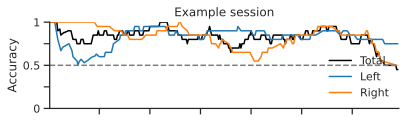

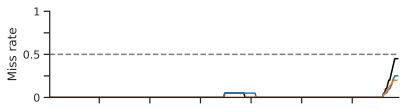

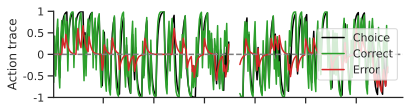

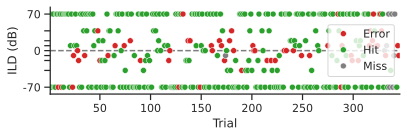

In [70]:
df_session = df[df.Session == session_id].reset_index(drop=True)
plot_session_trace(df_session, trace='accuracy')
plot_session_trace(df_session, trace='miss')
plot_session_trace(df_session, trace='action')
plot_session_scatter(df_session)

## Example licks

In [79]:
experiment = '2AFC_6'  # Group with more control over lick-port positioning
df = glue_animals(experiment=experiment, path_session='glue_sessions', filter_drug=False, update=False, to_csv=False)
df = filter_behavior(df, clean_start=True, drop_miss=True, filter_drug=False)
df = df[df.P == 0.5].reset_index(drop=True)  # Only include sessions with P = 0.5
df = df[df.Drug.isna()].reset_index(drop=True)  # Only rest sessions
df = add_lick_data(df)  # Add lick data to the DataFrame
df.Subject = df.Subject.astype(int).astype(str).str.zfill(3)  # 0 padd subjects for consistent XXX ID and ensure string format

Removed 26730 trials from session start (AW and Warm Up trials)
Total:95k trials
0.05% of premature lick trials (before response window)
Port1In or Port2In are already lists


In [80]:
# Add accuracies per session
df['Accuracy'] = df.groupby('Session')['Hit'].transform('mean')
df['AccuracyLeft'] = df[df.Side == 0].groupby('Session')['Hit'].transform('mean')
df['AccuracyRight'] = df[df.Side == 1].groupby('Session')['Hit'].transform('mean')

# Get unique sessions with their accuracies, sorted by descending accuracy
df_sessions = df[['Subject', 'Session', 'Accuracy', 'AccuracyLeft', 'AccuracyRight']].drop_duplicates(subset='Accuracy').sort_values('Accuracy', ascending=False).reset_index(drop=True)

In [81]:
session_id = df_sessions.Session[0]
subject = df_sessions.Subject[0]
print(f'Session: {session_id}')
print(f'Subject: {subject}')

Session: 020_stage_training_v6_20250806-120049
Subject: 020


In [218]:
def daily_report_v6(df):

    # Import session to be parsed
    sounds = pd.read_csv(Path.home() / 'PycharmProjects' / 'create_sounds' / 'sounds_6.1.csv')
    ilds = list(sounds.ILD.unique())

    ####################################################################################################################

    # Plotting style
    ms = 3  # (mpl default for plt.plot=6 and for plt.scatter=6**2)
    lw = 1.5  # mpl default
    # width = lw  # Arrow
    # head_width = 3 * width
    # head_length = 0.1 # 1.5 * head_width

    ####################################################################################################################

    # SUMMARY VARIABLES

    # Trials
    trials = len(df)
    trials_left = df.Side.value_counts()[0]
    trials_right = df.Side.value_counts()[1]

    # Hits
    hits = df.Hit.sum().astype(int)
    hits_left = df.Hit[df.Side == 0].sum().astype(int)
    hits_right = df.Hit[df.Side == 1].sum().astype(int)

    # Errors
    errors = df.WrongLick.sum().astype(int) + df.Punish.sum().astype(int)
    errors_left = df.WrongLick[df.Side == 0].sum().astype(int) + df.Punish[
        df.Side == 0].sum().astype(int)
    errors_right = df.WrongLick[df.Side == 1].sum().astype(int) + df.Punish[
        df.Side == 1].sum().astype(int)

    # Responses (valid trials)
    responses = df.Response.sum()
    responses_left = df.Response[df.Side == 0].sum()
    responses_right = df.Response[df.Side == 1].sum()

    # Performance (response rate)
    performance = responses / trials
    performance_left = responses_left / trials_left
    performance_right = responses_right / trials_right

    # Accuracy (hit rate)
    accuracy = hits / responses
    accuracy_left = hits_left / responses_left
    accuracy_right = hits_right / responses_right

    # Misses (invalid trials)
    misses = df.Miss.sum()
    misses_left = df.Miss[df.Side == 0].sum()
    misses_right = df.Miss[df.Side == 1].sum()

    # Miss rate
    miss_rate = misses / trials
    miss_rate_left = misses_left / trials_left
    miss_rate_right = misses_right / trials_right

    # Reward
    rewards = df.Reward.sum()
    rewards_left = df.Reward[df.Side == 0].sum()
    rewards_right = df.Reward[df.Side == 1].sum()

    # Reward size
    reward_sizes = df.RewardSize[df.Reward == 1].sum()  # Only rewarded trials
    reward_sizes_left = df.RewardSize[(df.Reward == 1) & (df.Side == 0)].sum()
    reward_sizes_right = df.RewardSize[(df.Reward == 1) & (df.Side == 1)].sum()

    # Water
    drop_size = 2.5  # μL
    # water = rewards * drop_size
    water = reward_sizes * drop_size
    # water_left = rewards_left * drop_size
    water_left = reward_sizes_left * drop_size
    # water_right = rewards_right * drop_size
    water_right = reward_sizes_right * drop_size

    # Sound
    sounds_mismatch = len(np.where(df.Filename != df.Filename2)[0])
    no_sound = len(np.where(df.Sound == 0)[0])
    message_count = len(np.where(df.Message != 'nan')[0])
    sound_errors = sounds_mismatch + no_sound + message_count

    ####################################################################################################################

    with PdfPages(df.Session.unique()[0] + '.pdf') as pdf:

        ################################################################################################################
        ################################################################################################################

        # PAGE 2

        fig = plt.figure(figsize=(8.27-2, 11.69-2))  # A4 size in inches portrait
        # fig = plt.figure(figsize=(11.69, 8.27))  # A4 size in inches landscape

        # Set max xlim for lick rasters and histograms
        # xlim_max = df.RespWin.unique()[0] + df.StimDur.unique()[0] + df.Delay.unique()[0] + df.Timeout.unique()[0]
        xlim_max = df.RespWin.unique()[0] + df.StimDur.unique()[0] + df.VarDelay.unique()[0] + df.Timeout.unique()[0]

        # PLOT 5: PERISTIMULUS LICK RASTER

        time_start_raster = time.time()

        # fig = plt.figure()
        xlim = [[], []]  # Initialize empty list to store left and right xlim
        ylim = [[], []]  # Initialize empty list to store left and right ylim

        for k in range(len(df.Side.unique())):  # k=0 left trials and k=1 right trials

            if k == 0:  # Left subplot: left trials
                # ax = plt.subplot2grid((1, 2), (0, 0))
                ax = plt.subplot2grid((16, 4), (0, 0), rowspan=12, colspan=2)
                stim_color = 'tab:blue'
                ax.set_title('Left')
                # ax.set_xlabel('Time (s) from stimulus onset')
                ax.set_xticklabels([])
                ax.set_ylabel('Trial')
                ax.spines['top'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['right'].set_visible(False)
            else:  # Right subplot: right trials
                # ax = plt.subplot2grid((1, 2), (0, 1))
                ax = plt.subplot2grid((16, 4), (0, 2), rowspan=12, colspan=2)
                stim_color = 'tab:orange'
                ax.set_title('Right')
                # ax.set_xlabel('Time (s) from stimulus onset')
                ax.set_xticklabels([])
                ax.spines['top'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['left'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.set_yticklabels([])

            df_side = df[df.Side == k].reset_index()

            for j in range(len(df_side)):  # n trials

                # Plot stimulus length
                ax.barh(df_side.index.values[j],
                        df_side.StimLen[j],
                        left=df_side.StimStart[j] -
                             df_side.StimStart[j],
                        color=stim_color, alpha=0.5, label='Stim', zorder=1)  # Need to specify zorder otherwise
                # response window is plotted under stimulus length and can't be seen

                # Define response window color according to trial outcome
                if df_side.WrongLick[j] == 1.0:
                    resp_win_color = 'tab:pink'
                elif df_side.Hit[j] == 0.0:
                    # resp_win_color = 'tab:red'
                    resp_win_color = 'tab:gray'
                elif df_side.Hit[j] == 1.0:
                    # resp_win_color = 'tab:green'
                    resp_win_color = 'tab:gray'
                elif np.isnan(df_side.Hit[j]):
                    # resp_win_color = 'tab:gray'
                    resp_win_color = 'tab:gray'

                # # Plot delay length
                # ax.barh(df_side.index.values[j],
                #         df_side.Delay[j],
                #         left=df_side.RespWinStart[j] -
                #              df_side.StimStart[j] - df_side.Delay[j],
                #         color='lightgray', zorder=2)

                # Plot variable delay length
                ax.barh(df_side.index.values[j],
                        df_side.VarDelay[j],
                        left=df_side.RespWinStart[j] -
                             df_side.StimStart[j] - df_side.VarDelay[j],
                        color='lightgray', zorder=2)

                # Plot response window length
                ax.barh(df_side.index.values[j],
                        df_side.RespWinLen[j],
                        left=df_side.RespWinStart[j] -
                             df_side.StimStart[j],
                        color=resp_win_color, zorder=2)

                # Plot end response window end
                ax.barh(df_side.index.values[j],
                        0.05,  # Arbitrary small length to mark response window end
                        left=df_side.RespWinEnd[j] -
                             df_side.StimStart[j] + 1,
                        color='k', zorder=2)

                # Plot reward
                if df_side.Reward[j] == 1:
                    ax.barh(df_side.index.values[j],
                            df_side.Timeout[j],  # Same length as TimeOut as valve time is too short to be seen
                            left=df_side.RespWinEnd[j] -
                                 df_side.StimStart[j],
                            color='tab:green', alpha=0.5, zorder=2)

                # Plot timeout
                if df_side.Punish[j] == 1:
                    ax.barh(df_side.index.values[j],
                            df_side.Timeout[j],
                            left=df_side.RespWinEnd[j] -
                                 df_side.StimStart[j],
                            color='tab:red', alpha=0.5, zorder=2)

                # Left licks
                for i in range(len(df_side.Port1In[j])):  # n licks

                    # If licks are after stimulus onset, draw markeredgecolor so it can be seen over stimulus length barh
                    if df_side.Port1In[j][i] - \
                            df_side.StimStart[j] > \
                            df_side.StimStart[j] - \
                            df_side.StimStart[j]:
                        ms = 2
                        mec = 'k'
                        mew = 0.1
                    else:
                        ms = 1
                        mec = 'tab:blue'
                        mew = None

                    if not df_side.Port1In[j]:
                        pass
                    else:
                        ax.plot(df_side.Port1In[j][i] -
                                df_side.StimStart[j],
                                df_side.index[j], marker='o', ms=ms,
                                mec=mec, mew=mew, color='tab:blue', zorder=3)
                        # markersize=200 / len(df.Side == 0))
                        # markersize = ax.containers[1][0].get_height()

                # Right licks
                for i in range(len(df_side.Port2In[j])):  # n licks

                    # If licks are after stimulus onset, draw markeredgecolor so it can be seen over stimulus length barh
                    if df_side.Port2In[j][i] - \
                            df_side.StimStart[j] > \
                            df_side.StimStart[j] - \
                            df_side.StimStart[j]:
                        ms = 2
                        mec = 'k'
                        mew = 0.1
                    else:
                        ms = 1
                        mec = 'tab:orange'
                        mew = None

                    if not df_side.Port2In[j]:
                        pass
                    else:
                        ax.plot(df_side.Port2In[j][i] -
                                df_side.StimStart[j],
                                df_side.Port2In.index[j], marker='o', ms=ms,
                                mec=mec, mew=mew, color='tab:orange', zorder=3)
                        # markersize=200 / len(df.Side == 1))
                        # markersize = ax.containers[1][0].get_height()

            xlim[k] = [ax.get_xlim()]  # Store xlim from left and right lick rasters
            # ax.set_xlim([-2, xlim[k][0][1]])  # Set xlim from -2 to trial end to zoom in and cut the fixation
            ylim[k] = [ax.get_ylim()]  # Store upper ylim from left and right lick rasters
            # ax.set_xlim([0, xlim_max])  # Set xlim from -1 to trial end to zoom in and cut the fixation
            ax.set_xlim([0, 4])  # Set xlim from -1 to trial end to zoom in and cut the fixation
            ax.set_ylim([0, max(trials_left, trials_right)])

        # Custom legend
        legend_elements = [Patch(facecolor='tab:blue', label='Left stim.'),
                           Patch(facecolor='tab:orange', label='Right stim.'),
                           Patch(facecolor='lightgray', label='Delay'),
                           Patch(facecolor='tab:gray', label='RT'),
                           Patch(facecolor='tab:green', label='Correct'),
                           Patch(facecolor='tab:red', label='Error'),
                           # Patch(facecolor='tab:pink', label='WrongLick'),
                           Line2D([0], [0], marker='o', color='w', label='Left licks', markerfacecolor='tab:blue'),
                           Line2D([0], [0], marker='o', color='w', label='Right licks', markerfacecolor='tab:orange'),
                           Line2D([0], [0], marker='|', color='k', label='Motor out', ls='none')]

        ax.legend(handles=legend_elements, handlelength=1, loc='upper right', ncol=3, frameon=True)

        time_end_raster = time.time()
        runtime_raster = time_end_raster - time_start_raster
        print("'Plot 5: peristimulus lick raster' took", round(runtime_raster, 2), 'seconds to run')

        ################################################################################################################

        # PLOT 6: PERISTIMULUS ALL LICKS HISTOGRAM

        time_start_psth_all = time.time()

        # fig = plt.figure()

        bin_size = 0.1

        axes_handles = []  # Store handles for plot axes as they will be overwritten by the next iteration
        ylim = [[], []]  # Initialize empty list to store left and right ylim
        licks = [[], []]  # List of lists: left [0], right [1] trials with left [0] and right [1] licks

        for k in range(len(df.Side.unique())):  # k=0 left trials and k=1 right trials

            histcounts_L = []
            histcounts_R = []

            left_licks_per_trial = []
            right_licks_per_trial = []

            if k == 0:  # Left subplot: left trials
                # ax = plt.subplot2grid((1, 2), (0, 0))
                ax = plt.subplot2grid((16, 4), (12, 0), rowspan=2, colspan=2)
                axes_handles.append(ax)
                # ax.set_title('Left trials')
                ax.set_xlabel('Time (s) from stimulus onset')
                ax.set_xlim(xlim[k][0])  # Use the same xlim that left raster
                # ax.set_xticklabels([])
                ax.set_ylabel('Licks/s')
                ax.spines['top'].set_visible(False)
                # ax.spines['bottom'].set_visible(False)
                ax.spines['right'].set_visible(False)
            else:  # Right subplot: right trials
                # ax = plt.subplot2grid((1, 2), (0, 1))
                ax = plt.subplot2grid((16, 4), (12, 2), rowspan=2, colspan=2)
                axes_handles.append(ax)
                # ax.set_title('Right trials')
                ax.set_xlabel('Time (s) from stimulus onset')
                ax.set_xlim(xlim[k][0])  # Use the same xlim that right raster
                # ax.set_xticklabels([])
                ax.spines['top'].set_visible(False)
                # ax.spines['bottom'].set_visible(False)
                ax.spines['left'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.set_yticklabels([])

            df_side = df[df.Side == k].reset_index()

            for j in range(len(df_side)):  # n trials

                # Left licks
                for i in range(len(df_side.Port1In[j])):  # n licks
                    left_licks_per_trial.append(len(df_side.Port1In[j]))
                    if not df_side.Port1In[j]:
                        pass
                    else:
                        histcounts_L.append(df_side.Port1In[j][i] -
                                            df_side.StimStart[j])

                # Right licks
                for i in range(len(df_side.Port2In[j])):  # n licks
                    right_licks_per_trial.append(len(df_side.Port2In[j]))
                    if not df_side.Port2In[j]:
                        pass
                    else:
                        histcounts_R.append(df_side.Port2In[j][i] -
                                            df_side.StimStart[j])

            # ax.hist(histcounts_L, density=True, histtype='step', color='tab:blue', label='Left licks')
            # ax.hist(histcounts_R, density=True, histtype='step', color='tab:orange', label='Right licks')

            ylim[k] = [max(histcounts_L), max(histcounts_R)]  # Store ylims from a side
            licks[k] = [left_licks_per_trial, right_licks_per_trial]

            # Calculate the number of bins
            n_bins = int((xlim[k][0][1] - (-2)) / bin_size)

            ax.hist(histcounts_L, histtype='step', color='tab:blue', edgecolor='tab:blue' , label='Left',
                    bins=np.linspace(-2, xlim[k][0][1], n_bins),
                    weights=np.repeat((1 / len((df_side.Miss == 0))) / bin_size, len(histcounts_L)))
            ax.hist(histcounts_R, histtype='step', color='tab:orange', edgecolor='tab:orange', label='Right',
                    bins=np.linspace(-2, xlim[k][0][1], n_bins),
                    weights=np.repeat((1 / len((df_side.Miss == 0))) / bin_size, len(histcounts_R)))

            # ax.set_xlim([-2, xlim[k][0][1]])  # Set xlim from -2 to trial end to zoom in and cut the fixation
            # ax.set_xlim([0, xlim_max])  # Set xlim from -1 to trial end to zoom in and cut the fixation
            ax.set_xlim([0, 4])  # Set xlim from -1 to trial end to zoom in and cut the fixation

        # Find the maximum y-axis limit across all handles
        max_ylim = max(ax.get_ylim()[1] for ax in axes_handles)

        # Set the same maximum y-axis limit for all handles
        for ax in axes_handles:
            ax.set_ylim([0, max_ylim])

        ax.legend(loc='upper right', handlelength=1, frameon=False)

        time_end_psth_all = time.time()
        runtime_psth_all = time_end_psth_all - time_start_psth_all
        print("'Plot 6: peristimulus lick histogram (all licks)' took", round(runtime_psth_all, 2), 'seconds to run')

        # ################################################################################################################
        #
        # # PLOT 8: PERISTIMULUS FIRST LICK HISTOGRAM
        #
        # time_start_psth_first = time.time()
        #
        # # fig = plt.figure()
        #
        # axes_handles = []  # Store handles for plot axes as they will be overwritten by the next iteration
        # ylim = [[], []]  # Initialize empty list to store left and right ylim
        #
        # for k in range(len(df.Side.unique())):  # k=0 left trials and k=1 right trials
        #
        #     first_lick_L = []
        #     first_lick_R = []
        #
        #     if k == 0:  # Left subplot: left trials
        #         # ax = plt.subplot2grid((1, 2), (0, 0))
        #         ax = plt.subplot2grid((16, 4), (14, 0), rowspan=2, colspan=2)
        #         axes_handles.append(ax)
        #         # ax.set_title('Left trials')
        #         ax.set_xlim([0, 2])  # Only interested in what happens during the first 2s
        #         ax.set_xlabel('Time (s)')
        #         ax.set_ylabel('First lick\n(licks/s)')
        #         ax.spines['top'].set_visible(False)
        #         ax.spines['right'].set_visible(False)
        #         # ax.patch.set_facecolor('none')
        #     else:  # Right subplot: right trials
        #         # ax = plt.subplot2grid((1, 2), (0, 1))
        #         ax = plt.subplot2grid((16, 4), (14, 2), rowspan=2, colspan=2)
        #         axes_handles.append(ax)
        #         # ax.set_title('Right trials')
        #         ax.set_xlim([0, 2])
        #         ax.set_xlabel('Time (s)')
        #         ax.spines['top'].set_visible(False)
        #         ax.spines['left'].set_visible(False)
        #         ax.spines['right'].set_visible(False)
        #         # ax.patch.set_facecolor('none')
        #         ax.set_yticklabels([])
        #
        #     df_side = df[df.Side == k].reset_index()
        #
        #     for j in range(len(df_side)):  # n trials
        #
        #         # Left licks
        #         for i in range(len(df_side.Port1In[j])):  # n licks
        #             if not df_side.Port1In[j]:
        #                 pass
        #             else:
        #                 if df_side.Port1In[j][i] - \
        #                         df_side.StimStart[j] < df_side.RespWinStart[
        #                     j] - df_side.StimStart[j]:
        #                     first_lick_L.append(df_side.Port1In[j][i] -
        #                                         df_side.StimStart[j])
        #                 elif df_side.Port1In[j][i] - \
        #                         df_side.StimStart[j] > df_side.RespWinStart[
        #                     j] - df_side.StimStart[j]:
        #                     first_lick_L.append(df_side.Port1In[j][i] -
        #                                         df_side.StimStart[j])
        #                     break
        #
        #         # Right licks
        #         for i in range(len(df_side.Port2In[j])):  # n licks
        #             if df_side.Port2In[j] == []:
        #                 # if not df.Port1In[j]:  # Equivalent
        #                 pass
        #             else:
        #                 if df_side.Port2In[j][i] - \
        #                         df_side.StimStart[j] < df_side.RespWinStart[
        #                     j] - df_side.StimStart[j]:
        #                     first_lick_R.append(df_side.Port2In[j][i] -
        #                                         df_side.StimStart[j])
        #                 elif df_side.Port2In[j][i] - \
        #                         df_side.StimStart[j] > df_side.RespWinStart[
        #                     j] - df_side.StimStart[j]:
        #                     first_lick_R.append(df_side.Port2In[j][i] -
        #                                         df_side.StimStart[j])
        #                     break
        #
        #     # ax.hist(first_lick_L, density=True, histtype='step', color='tab:blue', label='Left')
        #     # ax.hist(first_lick_R, density=True, histtype='step', color='tab:orange', label='Right')
        #
        #     ylim[k] = [max(histcounts_L), max(histcounts_R)]  # Store ylims from a side
        #
        #     ax.hist(first_lick_L, histtype='step', color='tab:blue', label='Left licks',
        #             bins=np.linspace(0, 2),
        #             weights=np.repeat((1 / len(df[(df.Miss == 0) & (df.Side == 0)])) / bin_size,
        #                               len(first_lick_L)))
        #     ax.hist(first_lick_R, histtype='step', color='tab:orange', label='Right licks',
        #             bins=np.linspace(0, 2),
        #             weights=np.repeat((1 / len(df[(df.Miss == 0) & (df.Side == 1)])) / bin_size,
        #                               len(first_lick_R)))
        #
        #     ax.patch.set_facecolor('none')  # Make axes transparent so the xaxes labels from the upper plot are visible
        #     # ax.set_xlim([-1, xlim[k][0][1]])  # Set xlim from -1 to trial end to zoom in and cut the fixation
        #     ax.set_xlim([0, xlim_max])  # Set xlim from -1 to trial end to zoom in and cut the fixation
        #
        # # Find the maximum y-axis limit across all handles
        # max_ylim = max(ax.get_ylim()[1] for ax in axes_handles)
        #
        # # Set the same maximum y-axis limit for all handles
        # for ax in axes_handles:
        #     ax.set_ylim([0, max_ylim])
        #
        # # ax.legend(loc='upper right')

'Plot 5: peristimulus lick raster' took 1.49 seconds to run
'Plot 6: peristimulus lick histogram (all licks)' took 0.08 seconds to run


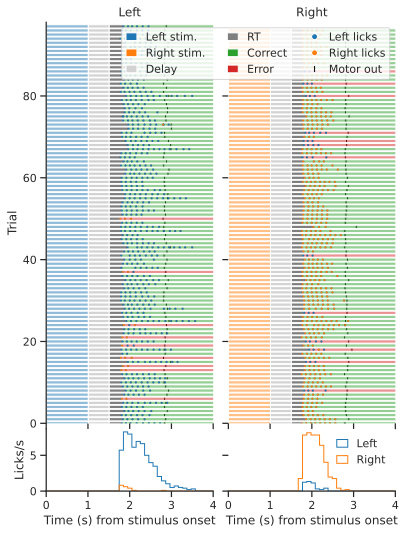

In [219]:
df_session = df[df.Session == session_id].iloc[1:].reset_index(drop=True)  # Skip first trial
daily_report_v6(df_session)

# Save figures

In [71]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt  # As HTML
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt  # As PDF
save_notebook_files(notebook_path='notebook.ipynb')  # Export all figures

Saved 5 images to notebook_files/
